# Week 1 Experiments

Three experiments:
- **Exp 2.1** — Standard horizon evaluation (96, 192, 336, 720 steps) on ETTh1, ETTh2, Weather
- **Exp 2.2** — Period decomposition preprocessing: remove trend+seasonal, feed residual to Panda, add back
- **Exp 1.1** — Dynamical diversity subsampling on Burgers: compare uniform vs PCA vs diversity-based channel selection

Run in the same kernel as the time series notebook if models are already loaded.
Otherwise run the setup cell below.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import welch, periodogram
from scipy.stats import spearmanr
from scipy.fft import fft, ifft, fftfreq
from scipy.linalg import svd
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cpu


In [2]:
# Skip this cell if models are already loaded in the kernel

import sys
sys.path.insert(0, './panda')

from panda.patchtst.pipeline import PatchTSTPipeline
from chronos import ChronosPipeline

panda_model = PatchTSTPipeline.from_pretrained(
    mode="predict",
    pretrain_path="GilpinLab/panda",
    device_map=device,
)

chronos_model = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.bfloat16,
)

print("Models loaded.")

Models loaded.


## 1. Shared Helpers

In [3]:
# -------------------------------------------------------
# Metrics
# -------------------------------------------------------
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-8
    return float(np.mean(2 * np.abs(y_true - y_pred) / denom))


# -------------------------------------------------------
# Instance normalisation
# -------------------------------------------------------
def instance_norm(x):
    """x: (T, C). Returns normalised array, mu, std."""
    mu  = x.mean(axis=0, keepdims=True)
    std = x.std( axis=0, keepdims=True) + 1e-8
    return (x - mu) / std, mu, std


# -------------------------------------------------------
# Inference wrappers
# -------------------------------------------------------
CONTEXT_LEN = 512


def panda_forecast(context_np, horizon):
    """context_np: (C, CONTEXT_LEN). Returns (C, horizon).
    Uses window autoregression for horizon > 128.
    """
    TRAIN_HORIZON = 128
    remaining = horizon
    ctx = context_np.copy()   # (C, CONTEXT_LEN)
    predictions = []

    while remaining > 0:
        h = min(TRAIN_HORIZON, remaining)
        context_t = torch.tensor(ctx.T, dtype=torch.float32)
        with torch.no_grad():
            pred = panda_model.predict(
                context_t, h,
                limit_prediction_length=False,
                sliding_context=True,
            )
        pred_np = pred.squeeze().cpu().numpy()  # (h, C) or (C, h)
        if pred_np.ndim == 1:
            pred_np = pred_np[:, None]
        # Ensure shape (C, h)
        if pred_np.shape[0] != context_np.shape[0]:
            pred_np = pred_np.T
        predictions.append(pred_np[:, :h])
        # Roll context forward
        ctx = np.concatenate([ctx[:, h:], pred_np[:, :h]], axis=1)
        remaining -= h

    return np.concatenate(predictions, axis=1)  # (C, horizon)


def chronos_forecast(context_np, horizon):
    """Batched: all channels in one call. Returns (C, horizon)."""
    ctx = torch.tensor(context_np, dtype=torch.float32)  # (C, T)
    with torch.no_grad():
        out = chronos_model.predict(
            ctx,
            prediction_length=horizon,
            num_samples=1,
        )
    return out[:, 0, :].cpu().numpy()  # (C, horizon)


# -------------------------------------------------------
# Generic sliding-window evaluator
# -------------------------------------------------------
def evaluate(data_CT, horizon, n_windows=8, label=""):
    """data_CT: (C, T_total), instance-normalised.
    Returns dict of metrics.
    """
    C, T = data_CT.shape
    max_start = T - CONTEXT_LEN - horizon
    if max_start <= 0:
        print(f"  [SKIP] {label}: not enough data")
        return None

    starts = np.linspace(0, max_start, n_windows, dtype=int)
    res    = {m: {"panda": [], "chronos": []}
              for m in ["mae", "mse", "smape"]}

    for s in starts:
        ctx = data_CT[:, s : s + CONTEXT_LEN]
        tgt = data_CT[:, s + CONTEXT_LEN : s + CONTEXT_LEN + horizon]

        p = panda_forecast(ctx, horizon)
        c = chronos_forecast(ctx, horizon)

        for name, pred in [("panda", p), ("chronos", c)]:
            res["mae"][name].append(mae(tgt, pred))
            res["mse"][name].append(mse(tgt, pred))
            res["smape"][name].append(smape(tgt, pred))

    summary = {"label": label, "horizon": horizon}
    for metric in ["mae", "mse", "smape"]:
        for model in ["panda", "chronos"]:
            vals = res[metric][model]
            summary[f"{model}_{metric}"] = np.median(vals)
    summary["panda_adv_mae"] = summary["chronos_mae"] - summary["panda_mae"]

    print(
        f"  {label:45s}  H={horizon:4d}  "
        f"Panda={summary['panda_mae']:.4f}  "
        f"Chronos={summary['chronos_mae']:.4f}  "
        f"Adv={summary['panda_adv_mae']:+.4f}"
    )
    return summary


all_results = []
print("Helpers defined.")

Helpers defined.


## Experiment 2.1 — Standard Horizon Evaluation

Run Panda and Chronos at horizons {96, 192, 336, 720} on ETTh1, ETTh2, Weather.
These are the standard benchmarks used by TimesNet, TQNet, PatchTST etc.
Panda was trained for horizon=128, so for 192/336/720 it uses window autoregression.

Goal: establish exactly how large the gap is at each horizon.

In [4]:
DATA_DIR  = "./ts_data"   # adjust to wherever you saved the CSVs
HORIZONS  = [96, 192, 336, 720]
N_WINDOWS = 6


def load_ts(path):
    """Load CSV, drop non-numeric, return (C, T) instance-normalised array."""
    df  = pd.read_csv(path)
    df  = df.select_dtypes(include=[np.number])
    arr = df.values.astype(np.float32)   # (T, C)
    arr, _, _ = instance_norm(arr)
    return arr.T                          # (C, T)


datasets = {
    "ETTh1"  : f"{DATA_DIR}/ETTh1.csv",
    "ETTh2"  : f"{DATA_DIR}/ETTh2.csv",
    "Weather": f"{DATA_DIR}/weather.csv",
}

print("Experiment 2.1: Standard Horizon Evaluation")
print("-" * 75)

exp21_results = []

for dname, dpath in datasets.items():
    try:
        data = load_ts(dpath)
        print(f"\n  {dname}: shape {data.shape}")
        for h in HORIZONS:
            res = evaluate(data, h, n_windows=N_WINDOWS, label=f"{dname}_H{h}")
            if res:
                res["dataset"] = dname
                exp21_results.append(res)
                all_results.append(res)
    except Exception as e:
        print(f"  ERROR on {dname}: {e}")

Experiment 2.1: Standard Horizon Evaluation
---------------------------------------------------------------------------

  ETTh1: shape (7, 17420)


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  ETTh1_H96                                      H=  96  Panda=0.5533  Chronos=0.5256  Adv=-0.0277


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  ETTh1_H192                                     H= 192  Panda=0.5652  Chronos=0.6090  Adv=+0.0437


...

  Weather_H192                                   H= 192  Panda=0.3863  Chronos=0.4568  Adv=+0.0705


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  Weather_H336                                   H= 336  Panda=0.4290  Chronos=0.4704  Adv=+0.0414


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  Weather_H720                                   H= 720  Panda=0.4943  Chronos=0.5480  Adv=+0.0537


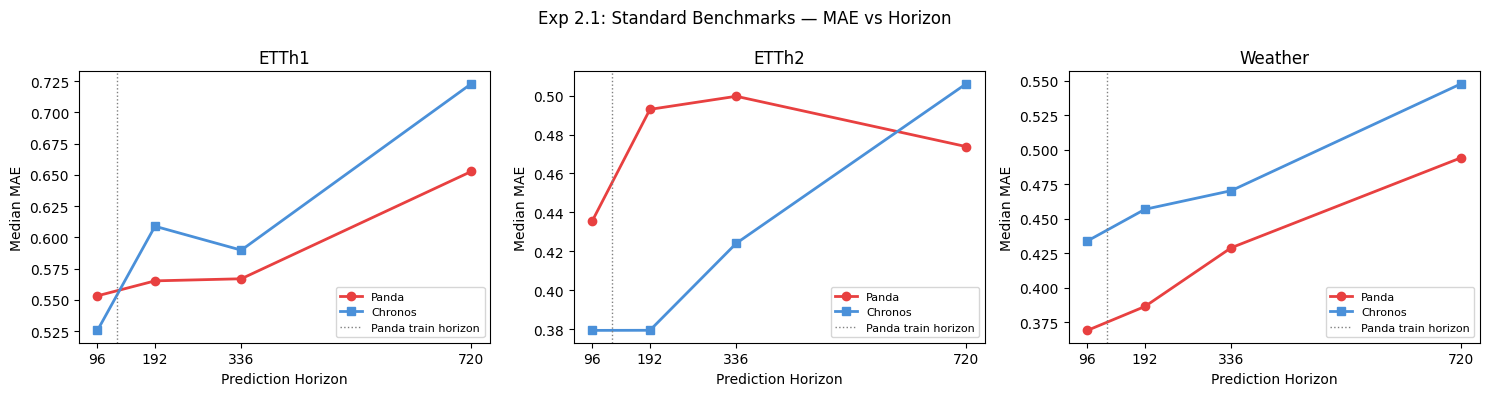


Full table:
       label  panda_mae  chronos_mae  panda_adv_mae
   ETTh1_H96     0.5533       0.5256        -0.0277
  ETTh1_H192     0.5652       0.6090         0.0437
  ETTh1_H336     0.5669       0.5898         0.0229
  ETTh1_H720     0.6528       0.7230         0.0702
   ETTh2_H96     0.4357       0.3793        -0.0564
  ETTh2_H192     0.4929       0.3794        -0.1135
  ETTh2_H336     0.4997       0.4241        -0.0756
  ETTh2_H720     0.4738       0.5061         0.0324
 Weather_H96     0.3690       0.4339         0.0649
Weather_H192     0.3863       0.4568         0.0705
Weather_H336     0.4290       0.4704         0.0414
Weather_H720     0.4943       0.5480         0.0537


In [5]:
# -------------------------------------------------------
# Figure 2.1: MAE vs horizon for each dataset
# -------------------------------------------------------
df_21 = pd.DataFrame(exp21_results)

if len(df_21) > 0:
    dataset_names = df_21["dataset"].unique()
    fig, axes = plt.subplots(1, len(dataset_names), figsize=(5 * len(dataset_names), 4))
    if len(dataset_names) == 1:
        axes = [axes]

    for ax, dname in zip(axes, dataset_names):
        sub = df_21[df_21["dataset"] == dname].sort_values("horizon")
        ax.plot(sub["horizon"], sub["panda_mae"],
                "o-", color="#E84040", linewidth=2, label="Panda")
        ax.plot(sub["horizon"], sub["chronos_mae"],
                "s-", color="#4A90D9", linewidth=2, label="Chronos")
        ax.axvline(128, color="gray", linestyle=":",
                   linewidth=1, label="Panda train horizon")
        ax.set_xlabel("Prediction Horizon")
        ax.set_ylabel("Median MAE")
        ax.set_title(dname)
        ax.legend(fontsize=8)
        ax.set_xticks(HORIZONS)

    plt.suptitle("Exp 2.1: Standard Benchmarks — MAE vs Horizon", fontsize=12)
    plt.tight_layout()
    plt.savefig("exp21_standard_horizons.png", dpi=150)
    plt.show()

    print("\nFull table:")
    print(df_21[["label","panda_mae","chronos_mae","panda_adv_mae"]].round(4).to_string(index=False))

## Experiment 2.2 — Period Decomposition Preprocessing

Hypothesis: the residual of a real-world time series (after removing trend and seasonality)
is more structurally similar to what Panda was trained on.

Pipeline:
1. Decompose each channel: signal = trend + seasonal + residual  (STL decomposition)
2. Feed only the residual to Panda/Chronos
3. Add back the trend+seasonal of the ground truth for evaluation
4. Compare against vanilla (no decomposition)

No retraining required.

In [6]:
def stl_decompose(series_1d, period=24):
    """Decompose a 1D series using STL.
    Returns (trend, seasonal, residual) — each shape (T,).
    period: dominant seasonality in timesteps.
      ETT hourly: 24 (daily cycle)
      Weather  : 24 (daily cycle)
    """
    stl    = STL(series_1d, period=period, robust=True)
    result = stl.fit()
    return result.trend, result.seasonal, result.resid


def decompose_array(data_CT, period=24):
    """Decompose each channel of (C, T) array.
    Returns (trend_CT, seasonal_CT, residual_CT).
    """
    C, T = data_CT.shape
    trend    = np.zeros_like(data_CT)
    seasonal = np.zeros_like(data_CT)
    residual = np.zeros_like(data_CT)

    for c in range(C):
        t, s, r     = stl_decompose(data_CT[c], period=period)
        trend[c]    = t
        seasonal[c] = s
        residual[c] = r

    return trend, seasonal, residual


def evaluate_decomposed(data_CT, horizon, period=24, n_windows=6, label=""):
    """Run Panda and Chronos on the STL residual.
    At evaluation time, add back the ground truth trend+seasonal.
    Returns dict of metrics.
    """
    C, T = data_CT.shape
    max_start = T - CONTEXT_LEN - horizon
    if max_start <= 0:
        return None

    # Decompose the full series once
    print(f"    Decomposing {label} (C={C})...", end=" ", flush=True)
    trend, seasonal, residual = decompose_array(data_CT, period=period)
    deterministic = trend + seasonal   # what we add back
    print("done.")

    starts = np.linspace(0, max_start, n_windows, dtype=int)
    res    = {m: {"panda": [], "chronos": []}
              for m in ["mae", "mse"]}

    for s in starts:
        # Context window: residual only
        ctx_res = residual[:, s : s + CONTEXT_LEN]

        # Ground truth: original signal
        tgt_orig = data_CT[:, s + CONTEXT_LEN : s + CONTEXT_LEN + horizon]

        # Deterministic component of target window
        tgt_det  = deterministic[:, s + CONTEXT_LEN : s + CONTEXT_LEN + horizon]

        # Forecast residual
        p_res = panda_forecast(ctx_res, horizon)
        c_res = chronos_forecast(ctx_res, horizon)

        # Reconstruct: forecast = predicted_residual + deterministic
        p_full = p_res + tgt_det
        c_full = c_res + tgt_det

        for name, pred in [("panda", p_full), ("chronos", c_full)]:
            res["mae"][name].append(mae(tgt_orig, pred))
            res["mse"][name].append(mse(tgt_orig, pred))

    summary = {"label": label + "_decomp", "horizon": horizon}
    for metric in ["mae", "mse"]:
        for model in ["panda", "chronos"]:
            summary[f"{model}_{metric}"] = np.median(res[metric][model])
    summary["panda_adv_mae"] = summary["chronos_mae"] - summary["panda_mae"]

    print(
        f"  {label + '_decomp':45s}  H={horizon:4d}  "
        f"Panda={summary['panda_mae']:.4f}  "
        f"Chronos={summary['chronos_mae']:.4f}  "
        f"Adv={summary['panda_adv_mae']:+.4f}"
    )
    return summary


print("Decomposition helpers defined.")

Decomposition helpers defined.


In [7]:
# Periods: ETT is hourly -> period=24 (daily cycle)
# Weather is 10-min -> period=144 (daily cycle at 10-min resolution)
dataset_periods = {
    "ETTh1"  : 24,
    "ETTh2"  : 24,
    "Weather": 144,
}

# Only run at horizons 96 and 336 to save time
# (96 = within Panda training horizon, 336 = well beyond)
DECOMP_HORIZONS = [96, 336]

print("Experiment 2.2: Period Decomposition Preprocessing")
print("-" * 75)

exp22_results = []

for dname, dpath in datasets.items():
    try:
        data = load_ts(dpath)
        period = dataset_periods[dname]
        print(f"\n  {dname}: shape {data.shape}, period={period}")

        for h in DECOMP_HORIZONS:
            res = evaluate_decomposed(
                data, h, period=period,
                n_windows=N_WINDOWS, label=dname
            )
            if res:
                res["dataset"] = dname
                exp22_results.append(res)
                all_results.append(res)

    except Exception as e:
        print(f"  ERROR on {dname}: {e}")

Experiment 2.2: Period Decomposition Preprocessing
---------------------------------------------------------------------------

  ETTh1: shape (7, 17420), period=24
    Decomposing ETTh1 (C=7)... done.


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  ETTh1_decomp                                   H=  96  Panda=0.1940  Chronos=0.1891  Adv=-0.0048
    Decomposing ETTh1 (C=7)... done.


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  ETTh1_decomp                                   H= 336  Panda=0.2085  Chronos=0.2036  Adv=-0.0049

  ETTh2: shape (7, 17420), period=24
    Decomposing ETTh2 (C=7)... 

...

  ETTh2_decomp                                   H= 336  Panda=0.1406  Chronos=0.1389  Adv=-0.0017

  Weather: shape (21, 52696), period=144
    Decomposing Weather (C=21)... done.


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  Weather_decomp                                 H=  96  Panda=0.2241  Chronos=0.2476  Adv=+0.0235
    Decomposing Weather (C=21)... done.


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  Weather_decomp                                 H= 336  Panda=0.1882  Chronos=0.1861  Adv=-0.0022


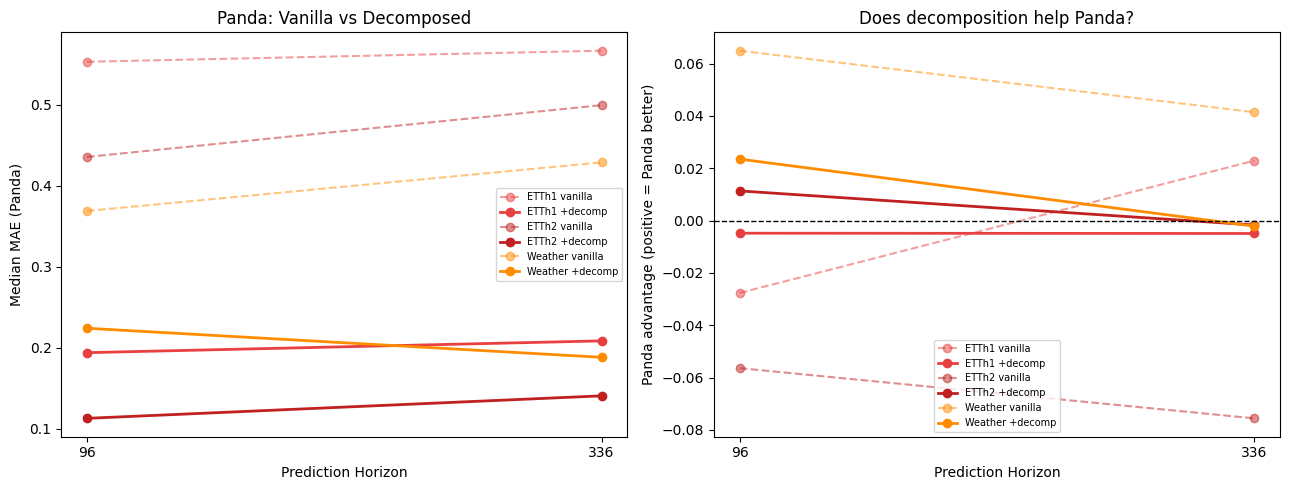

In [8]:
# -------------------------------------------------------
# Figure 2.2: Vanilla vs Decomposed — side by side
# -------------------------------------------------------
df_22 = pd.DataFrame(exp22_results)

# Merge with exp21 results for the same horizons
# to get a clean vanilla vs decomposed comparison

if len(df_22) > 0 and len(df_21) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Panel A: Panda — vanilla vs decomposed
    ax = axes[0]
    for dname, color in zip(
        ["ETTh1", "ETTh2", "Weather"],
        ["#E84040", "#C02020", "#FF8C00"]
    ):
        van  = df_21[(df_21["dataset"] == dname) &
                     (df_21["horizon"].isin(DECOMP_HORIZONS))].sort_values("horizon")
        decp = df_22[df_22["dataset"] == dname].sort_values("horizon")
        if len(van) > 0:
            ax.plot(van["horizon"],  van["panda_mae"],
                    "o--", color=color, linewidth=1.5,
                    alpha=0.5, label=f"{dname} vanilla")
        if len(decp) > 0:
            ax.plot(decp["horizon"], decp["panda_mae"],
                    "o-",  color=color, linewidth=2.0,
                    label=f"{dname} +decomp")

    ax.set_xlabel("Prediction Horizon")
    ax.set_ylabel("Median MAE (Panda)")
    ax.set_title("Panda: Vanilla vs Decomposed")
    ax.legend(fontsize=7)
    ax.set_xticks(DECOMP_HORIZONS)

    # Panel B: Panda advantage — vanilla vs decomposed
    ax = axes[1]
    for dname, color in zip(
        ["ETTh1", "ETTh2", "Weather"],
        ["#E84040", "#C02020", "#FF8C00"]
    ):
        van  = df_21[(df_21["dataset"] == dname) &
                     (df_21["horizon"].isin(DECOMP_HORIZONS))].sort_values("horizon")
        decp = df_22[df_22["dataset"] == dname].sort_values("horizon")
        if len(van) > 0:
            ax.plot(van["horizon"],  van["panda_adv_mae"],
                    "o--", color=color, linewidth=1.5,
                    alpha=0.5, label=f"{dname} vanilla")
        if len(decp) > 0:
            ax.plot(decp["horizon"], decp["panda_adv_mae"],
                    "o-",  color=color, linewidth=2.0,
                    label=f"{dname} +decomp")

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Prediction Horizon")
    ax.set_ylabel("Panda advantage (positive = Panda better)")
    ax.set_title("Does decomposition help Panda?")
    ax.legend(fontsize=7)
    ax.set_xticks(DECOMP_HORIZONS)

    plt.tight_layout()
    plt.savefig("exp22_decomposition.png", dpi=150)
    plt.show()

## Experiment 1.1 — Dynamical Diversity Subsampling

Compare three channel selection methods on 1D Burgers (nu=0.005):
- **Uniform:** every k-th spatial location (what we did before)
- **PCA:** global spatial modes (what we did before)
- **Diversity:** select locations whose time series are maximally dynamically diverse

Diversity selection: compute a feature vector per spatial location,
then run farthest-point sampling to pick maximally spread locations.

Features per location: [mean, std, dominant frequency, spectral entropy, approx Lyapunov]

In [9]:
# -------------------------------------------------------
# Burgers solver (reuse from spatiotemporal notebook)
# -------------------------------------------------------
from scipy.fft import fft, ifft, fftfreq

def simulate_burgers(T=1000, dt=0.01, N_x=128, nu=0.005, seed=42):
    rng    = np.random.default_rng(seed)
    k      = fftfreq(N_x, d=1.0/N_x).astype(complex)
    k_max  = N_x // 3
    dealias = np.abs(k) <= k_max

    u0_hat = np.zeros(N_x, dtype=complex)
    for m in range(1, 6):
        amp = rng.standard_normal() + 1j * rng.standard_normal()
        u0_hat[m]       += amp
        u0_hat[N_x - m] += np.conj(amp)
    u0_hat *= dealias

    L_op = -nu * k ** 2

    def rhs_hat(u_hat):
        u_phys = np.real(ifft(u_hat))
        nonlin = fft(0.5 * u_phys ** 2) * dealias
        return L_op * u_hat - 1j * k * nonlin

    U = np.zeros((T, N_x), dtype=np.float32)
    u_hat = u0_hat.copy()
    for t in range(T):
        U[t] = np.real(ifft(u_hat)).astype(np.float32)
        k1 = rhs_hat(u_hat)
        k2 = rhs_hat(u_hat + 0.5*dt*k1)
        k3 = rhs_hat(u_hat + 0.5*dt*k2)
        k4 = rhs_hat(u_hat +     dt*k3)
        u_hat = u_hat + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        u_hat *= dealias
        if not np.isfinite(u_hat).all():
            return U[:t]
    return U


# -------------------------------------------------------
# Preprocessing helpers
# -------------------------------------------------------
def pca_reduction(U, n_components):
    """(T, N_x) -> (T, n_comp) via PCA."""
    U_c   = U - U.mean(axis=0, keepdims=True)
    n_c   = min(n_components, min(U_c.shape) - 1)
    _, _, Vt = svd(U_c, full_matrices=False)
    return (U_c @ Vt[:n_c].T).astype(np.float32), Vt[:n_c]


def uniform_subsample(U, n_points):
    """(T, N_x) -> (T, n_points) via uniform spatial subsampling."""
    idx = np.linspace(0, U.shape[1]-1, n_points, dtype=int)
    return U[:, idx].astype(np.float32)


print("Burgers solver and preprocessing helpers defined.")

Burgers solver and preprocessing helpers defined.


In [10]:
# -------------------------------------------------------
# Dynamical feature extraction per spatial location
# -------------------------------------------------------
def dominant_frequency(ts):
    """Frequency with highest power in the power spectrum."""
    freqs, power = periodogram(ts)
    return float(freqs[np.argmax(power[1:]) + 1])  # skip DC


def spectral_entropy(ts):
    """Entropy of the normalised power spectrum."""
    _, power = periodogram(ts)
    p = power / (power.sum() + 1e-10)
    p = p[p > 1e-10]
    return float(-np.sum(p * np.log(p)))


def approx_lyapunov(ts, lag=1):
    """Fast proxy for Lyapunov exponent: average log-divergence of nearest neighbours."""
    ts   = np.array(ts)
    ts   = (ts - ts.mean()) / (ts.std() + 1e-10)
    N    = len(ts)
    diffs = []
    for i in range(0, N - lag - 10, 10):
        # find nearest neighbour excluding temporal neighbours
        dists = np.abs(ts - ts[i])
        dists[max(0, i-5):i+5] = np.inf
        j = np.argmin(dists)
        if dists[j] > 1e-10:
            d0 = dists[j]
            d1 = np.abs(ts[i + lag] - ts[j + lag]) if j + lag < N else d0
            if d1 > 1e-10:
                diffs.append(np.log(d1 / d0))
    return float(np.mean(diffs)) if diffs else 0.0


def compute_dynamical_features(U):
    """Compute feature vector for each spatial location in (T, N_x) field.
    Returns feature matrix (N_x, n_features).
    """
    T, N_x = U.shape
    features = []

    for x in range(N_x):
        ts = U[:, x].astype(float)
        feat = [
            float(np.mean(ts)),
            float(np.std(ts)),
            float(np.mean(np.abs(ts))),           # mean absolute value
            float(np.percentile(np.abs(ts), 90)), # 90th percentile magnitude
            dominant_frequency(ts),
            spectral_entropy(ts),
            approx_lyapunov(ts),
        ]
        features.append(feat)

    F = np.array(features)   # (N_x, n_features)
    # Normalise each feature to [0, 1] for distance computation
    F_min = F.min(axis=0, keepdims=True)
    F_max = F.max(axis=0, keepdims=True)
    F_norm = (F - F_min) / (F_max - F_min + 1e-8)
    return F_norm


def farthest_point_sampling(features, n_points):
    """Select n_points locations that are maximally spread in feature space.
    features: (N_x, n_features)
    Returns indices of selected locations.
    """
    N_x = features.shape[0]
    selected = [np.random.randint(0, N_x)]   # start from random point
    dists    = np.full(N_x, np.inf)

    for _ in range(n_points - 1):
        last = selected[-1]
        # Distance from last selected point to all others
        d = np.linalg.norm(features - features[last], axis=1)
        dists = np.minimum(dists, d)
        # Pick the farthest point
        dists[selected] = -np.inf   # exclude already selected
        selected.append(int(np.argmax(dists)))

    return sorted(selected)


def diversity_subsample(U, n_points):
    """(T, N_x) -> (T, n_points) via dynamical diversity sampling."""
    print(f"    Computing dynamical features for {U.shape[1]} locations...",
          end=" ", flush=True)
    features = compute_dynamical_features(U)
    indices  = farthest_point_sampling(features, n_points)
    print(f"done. Selected indices: {indices[:6]}...")
    return U[:, indices].astype(np.float32), indices, features


print("Diversity subsampling helpers defined.")

Diversity subsampling helpers defined.


In [11]:
# -------------------------------------------------------
# Run Experiment 1.1
# -------------------------------------------------------
print("Experiment 1.1: Dynamical Diversity Subsampling")
print("-" * 75)

N_CHANNELS = 16
nu_values  = [0.05, 0.01, 0.005]   # smooth -> chaotic
EVAL_H     = 128

exp11_results = []

for nu in nu_values:
    print(f"\n  nu={nu}:")
    U = simulate_burgers(T=1000, dt=0.01, N_x=128, nu=nu)
    print(f"    Simulated: shape {U.shape}")

    methods = {}

    # Method 1: Uniform subsampling
    methods["Uniform"] = uniform_subsample(U, N_CHANNELS)

    # Method 2: PCA
    U_pca, _ = pca_reduction(U, N_CHANNELS)
    methods["PCA"] = U_pca

    # Method 3: Diversity
    U_div, div_idx, div_features = diversity_subsample(U, N_CHANNELS)
    methods["Diversity"] = U_div

    for method_name, U_ch in methods.items():
        # Instance normalise
        U_norm, _, _ = instance_norm(U_ch)   # (T, C)
        U_CT = U_norm.T                       # (C, T)

        label = f"Burgers_nu={nu}_{method_name}"
        res   = evaluate(U_CT, EVAL_H, n_windows=6, label=label)
        if res:
            res["nu"]     = nu
            res["method"] = method_name
            exp11_results.append(res)
            all_results.append(res)

Experiment 1.1: Dynamical Diversity Subsampling
---------------------------------------------------------------------------

  nu=0.05:
    Simulated: shape (1000, 128)
    Computing dynamical features for 128 locations... done. Selected indices: [1, 3, 4, 5, 11, 23]...


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  Burgers_nu=0.05_Uniform                        H= 128  Panda=0.0139  Chronos=0.0427  Adv=+0.0288


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  Burgers_nu=0.05_PCA                            H= 128  Panda=0.1091  Chronos=0.2365  Adv=+0.1275


...

  Burgers_nu=0.005_Uniform                       H= 128  Panda=0.0145  Chronos=0.0615  Adv=+0.0470


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  Burgers_nu=0.005_PCA                           H= 128  Panda=0.1231  Chronos=0.2373  Adv=+0.1142


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  Burgers_nu=0.005_Diversity                     H= 128  Panda=0.0159  Chronos=0.0816  Adv=+0.0657


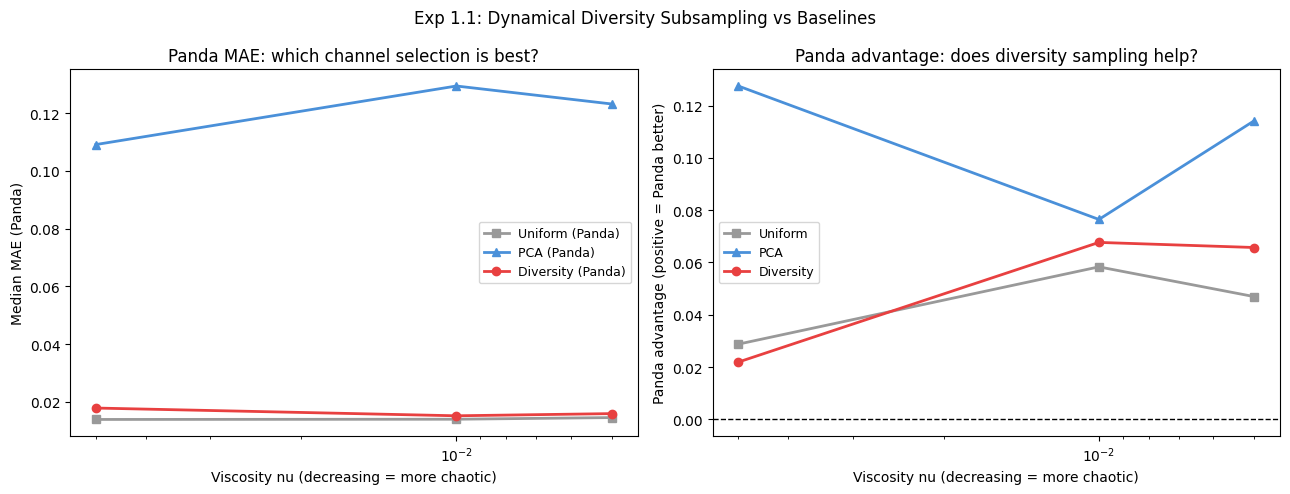

In [12]:
# -------------------------------------------------------
# Figure 1.1A: MAE comparison across methods
# -------------------------------------------------------
df_11 = pd.DataFrame(exp11_results)

if len(df_11) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    method_colors  = {"Uniform": "#999999", "PCA": "#4A90D9", "Diversity": "#E84040"}
    method_markers = {"Uniform": "s",       "PCA": "^",       "Diversity": "o"}

    # Panel A: Panda MAE vs nu for each method
    ax = axes[0]
    for method in ["Uniform", "PCA", "Diversity"]:
        sub = df_11[df_11["method"] == method].sort_values("nu", ascending=False)
        ax.plot(sub["nu"], sub["panda_mae"],
                marker=method_markers[method], linewidth=2,
                color=method_colors[method], label=f"{method} (Panda)")

    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("Viscosity nu (decreasing = more chaotic)")
    ax.set_ylabel("Median MAE (Panda)")
    ax.set_title("Panda MAE: which channel selection is best?")
    ax.legend(fontsize=9)

    # Panel B: Panda advantage vs nu for each method
    ax = axes[1]
    for method in ["Uniform", "PCA", "Diversity"]:
        sub = df_11[df_11["method"] == method].sort_values("nu", ascending=False)
        ax.plot(sub["nu"], sub["panda_adv_mae"],
                marker=method_markers[method], linewidth=2,
                color=method_colors[method], label=method)

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("Viscosity nu (decreasing = more chaotic)")
    ax.set_ylabel("Panda advantage (positive = Panda better)")
    ax.set_title("Panda advantage: does diversity sampling help?")
    ax.legend(fontsize=9)

    plt.suptitle("Exp 1.1: Dynamical Diversity Subsampling vs Baselines", fontsize=12)
    plt.tight_layout()
    plt.savefig("exp11_diversity_subsampling.png", dpi=150)
    plt.show()

    Computing dynamical features for 128 locations... done. Selected indices: [2, 15, 16, 27, 35, 58]...


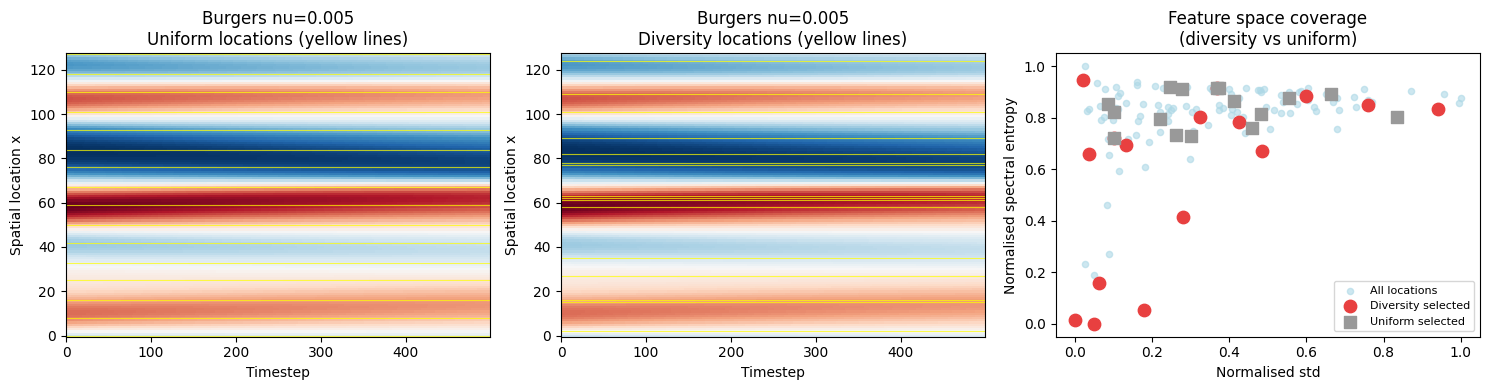

In [13]:
# -------------------------------------------------------
# Figure 1.1B: Visualise which locations were selected
# -------------------------------------------------------
# Use nu=0.005 (most chaotic) for this visualisation
U_vis = simulate_burgers(T=500, dt=0.01, N_x=128, nu=0.005)
_, div_idx_vis, feat_vis = diversity_subsample(U_vis, N_CHANNELS)
uni_idx_vis = np.linspace(0, 127, N_CHANNELS, dtype=int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Spacetime plot with selected locations marked
for ax, idx, title in zip(
    axes,
    [uni_idx_vis, div_idx_vis],
    ["Uniform locations", "Diversity locations"],
):
    ax.imshow(U_vis.T, aspect='auto', origin='lower',
              cmap='RdBu_r', interpolation='nearest')
    for x in idx:
        ax.axhline(x, color='yellow', linewidth=0.8, alpha=0.7)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Spatial location x")
    ax.set_title(f"Burgers nu=0.005\n{title} (yellow lines)")

# Feature space: plot locations in (std, spectral_entropy) space
ax = axes[2]
ax.scatter(feat_vis[:, 1], feat_vis[:, 5],   # std vs spectral entropy
           c='lightblue', s=20, alpha=0.6, label='All locations')
ax.scatter(feat_vis[div_idx_vis, 1], feat_vis[div_idx_vis, 5],
           c='#E84040', s=80, zorder=3, label='Diversity selected')
ax.scatter(feat_vis[uni_idx_vis, 1], feat_vis[uni_idx_vis, 5],
           c='#999999', s=80, marker='s', zorder=3, label='Uniform selected')
ax.set_xlabel("Normalised std")
ax.set_ylabel("Normalised spectral entropy")
ax.set_title("Feature space coverage\n(diversity vs uniform)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("exp11_location_visualisation.png", dpi=150)
plt.show()

## Final Summary

In [14]:
# Compile all results
df_all = pd.DataFrame(all_results)

print("=" * 75)
print("WEEK 1 EXPERIMENT SUMMARY")
print("=" * 75)

print("\nExp 2.1 — Standard Horizons:")
print(pd.DataFrame(exp21_results)[
    ["label","panda_mae","chronos_mae","panda_adv_mae"]
].round(4).to_string(index=False))

print("\nExp 2.2 — Decomposition Preprocessing:")
if exp22_results:
    print(pd.DataFrame(exp22_results)[
        ["label","panda_mae","chronos_mae","panda_adv_mae"]
    ].round(4).to_string(index=False))

print("\nExp 1.1 — Diversity Subsampling:")
print(pd.DataFrame(exp11_results)[
    ["label","panda_mae","chronos_mae","panda_adv_mae"]
].round(4).to_string(index=False))

df_all.to_csv("week1_results.csv", index=False)
print("\nSaved week1_results.csv")

WEEK 1 EXPERIMENT SUMMARY

Exp 2.1 — Standard Horizons:
       label  panda_mae  chronos_mae  panda_adv_mae
   ETTh1_H96     0.5533       0.5256        -0.0277
  ETTh1_H192     0.5652       0.6090         0.0437
  ETTh1_H336     0.5669       0.5898         0.0229
  ETTh1_H720     0.6528       0.7230         0.0702
   ETTh2_H96     0.4357       0.3793        -0.0564
  ETTh2_H192     0.4929       0.3794        -0.1135
  ETTh2_H336     0.4997       0.4241        -0.0756
  ETTh2_H720     0.4738       0.5061         0.0324
 Weather_H96     0.3690       0.4339         0.0649
Weather_H192     0.3863       0.4568         0.0705
Weather_H336     0.4290       0.4704         0.0414
Weather_H720     0.4943       0.5480         0.0537

Exp 2.2 — Decomposition Preprocessing:
         label  panda_mae  chronos_mae  panda_adv_mae
  ETTh1_decomp     0.1940       0.1891        -0.0048
  ETTh1_decomp     0.2085       0.2036        -0.0049
  ETTh2_decomp     0.1128       0.1242         0.0113
  ETTh2_deco